In [1]:
from Neuron import Neuron
from Layer import Layer
from Network import Network
from Activations import Activation

import numpy as np
import random
import pandas as pd
import math

import plotly.express as plt

In [2]:
import struct
import numpy as np


def load_images(path):
    with open(path, "rb") as file:
        magic, count, rows, columns = struct.unpack(">IIII", file.read(16))
        if magic != 2051:
            raise ValueError(f"Unexpected image magic number: {magic}")

        images = np.frombuffer(
            file.read(),
            dtype=np.uint8,
        )

    return images.reshape(count, rows * columns)


def load_labels(path):
    with open(path, "rb") as file:
        magic, count = struct.unpack(">II", file.read(8))
        if magic != 2049:
            raise ValueError(f"Unexpected label magic number: {magic}")

        return np.frombuffer(file.read(), dtype=np.uint8)

In [3]:
train_images = load_images("data/archive/train-images.idx3-ubyte")
train_labels = load_labels("data/archive/train-labels.idx1-ubyte")

test_images = load_images("data/archive/t10k-images.idx3-ubyte")
test_labels = load_labels("data/archive/t10k-labels.idx1-ubyte")

print(train_images.shape)  # (60000, 784)
print(train_labels.shape)  # (60000,)

(60000, 784)
(60000,)


In [4]:
test_labels

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,), dtype=uint8)

In [5]:
network = Network([
    (784, None), 
    (100, Activation.RELU),
    (100, Activation.RELU),
    (10, Activation.LINEAR)
])
network.initialize_random()

In [6]:
train_images = train_images.astype(float) / 255.0
test_images = test_images.astype(float) / 255.0

def one_hot(label, class_count=10):
    target = np.zeros(class_count)
    target[label] = 1.0
    return target

training_data = [
    (image, one_hot(label))
    for image, label in zip(train_images, train_labels)
]

testing_data = [
    (image, one_hot(label))
    for image, label in zip(test_images, test_labels)
]

In [7]:
predictions = np.array([
    network.forward(image)
    for image in test_images
])

predicted_labels = np.argmax(predictions, axis=1)
accuracy = np.mean(predicted_labels == test_labels)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 6.11%


In [8]:
def classification_accuracy(images, labels):
    # Inference only: no weight updates during evaluation.
    predicted = np.fromiter(
        (np.argmax(network.forward(image)) for image in images),
        dtype=int, count=len(images),
    )
    return float(np.mean(predicted == labels))


def report_accuracy(epoch, metrics):
    metrics['epoch'] = epoch
    metrics['train_accuracy'] = classification_accuracy(train_images, train_labels)
    metrics['test_accuracy'] = classification_accuracy(test_images, test_labels)
    print(f"Epoch {epoch}: train {metrics['train_accuracy']:.2%} | test {metrics['test_accuracy']:.2%}")


# Continues current weights; one call keeps the learning-rate schedule intact.
history = network.train(
    learning_rate=0.1,
    training_data=training_data,
    epochs=5,
    on_epoch_end=report_accuracy,
    shuffle=True,
    seed=42,
)
history_df = pd.DataFrame(history)
history_df



Epoch 1/5
  [##############################] 100.0% | average loss: 0.074250 | lr: 0.1
Epoch 1: train 94.77% | test 94.41%

Epoch 2/5
  [##############################] 100.0% | average loss: 0.042663 | lr: 0.1
Epoch 2: train 96.06% | test 95.15%

Epoch 3/5
  [##############################] 100.0% | average loss: 0.035974 | lr: 0.1
Epoch 3: train 96.61% | test 95.82%

Epoch 4/5
  [##############################] 100.0% | average loss: 0.031481 | lr: 0.1
Epoch 4: train 97.06% | test 95.91%

Epoch 5/5
  [##############################] 100.0% | average loss: 0.028798 | lr: 0.1
Epoch 5: train 97.22% | test 96.19%


,loss,learning_rate,epoch,train_accuracy,test_accuracy
0,0.074250,0.1,1,0.947750,0.9441
1,0.042663,0.1,2,0.960600,0.9515
2,0.035974,0.1,3,0.966100,0.9582
3,0.031481,0.1,4,0.970583,0.9591
4,0.028798,0.1,5,0.972167,0.9619


Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='epoch', ylabel='Accuracy'>

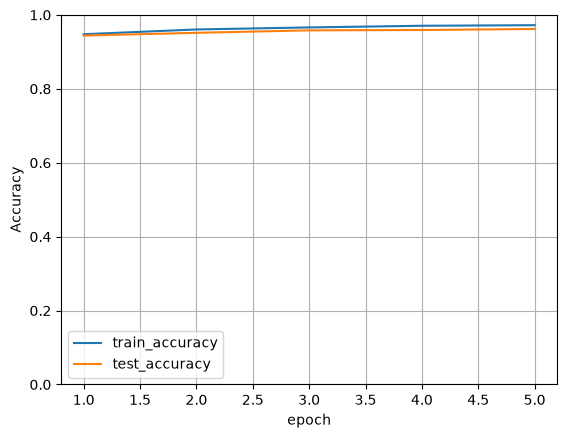

In [9]:
history_df.plot(x="epoch", y=["train_accuracy", "test_accuracy"],
                ylabel="Accuracy", ylim=(0, 1), grid=True)

In [10]:
predictions = np.array([
    network.forward(image)
    for image in test_images
])

predicted_labels = np.argmax(predictions, axis=1)
accuracy = np.mean(predicted_labels == test_labels)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 96.19%
